# MIMIC-IV Feature Impact Exploration

Measures how much each feature group contributes to predicting in-hospital mortality (Y1) and 30-day readmission (Y2) using mutual information.

**Feature groups analysed:**
- Demographics (age, gender, height, weight, BMI)
- Admission type (one-hot)
- Lab embedding norms (blood gas, chemistry, haematology, urine, …)
- Microbiology embedding norms
- Radiology, triage, chief complaint, diagnosis/discharge history embedding norms

## Section 1: Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.feature_selection import mutual_info_classif

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

REPO_ROOT       = Path.home() / "Python/HRS"
FULL_DATA       = REPO_ROOT / "data/preprocessing/full/full_cdss_dataset.parquet"
ADMISSIONS_FILE = Path.home() / "data/physionet.org/files/mimiciv/3.1/hosp/admissions.csv.gz"

# Load only scalar columns first; embeddings are processed one-at-a-time below
BASE_COLS = ["subject_id", "hadm_id", "y1_mortality", "y2_readmission", "demographic_vec"]
df = pd.read_parquet(FULL_DATA, columns=BASE_COLS)
print(f"Loaded base cols: {df.shape}")
print(f"Y1 mortality   : {df['y1_mortality'].sum():,}  ({df['y1_mortality'].mean()*100:.2f}%)")
print(f"Y2 readmission : {df['y2_readmission'].sum():,}  ({df['y2_readmission'].mean()*100:.2f}%)")


Loaded base cols: (546028, 5)
Y1 mortality   : 11,801  (2.16%)
Y2 readmission : 107,617.0  (20.14%)


## Section 2: Feature Extraction

In [2]:
# --- 2a: Expand demographic_vec into named scalar columns ---
# Vector layout from extract_demographics.py:
# [Age, Gender, Height(cm), Weight(kg), BMI, height_missing, weight_missing, bmi_missing]
DEMO_COLS = ["age", "gender", "height_cm", "weight_kg", "bmi",
             "height_missing", "weight_missing", "bmi_missing"]

demo_mat = np.stack(df["demographic_vec"].values)
for i, name in enumerate(DEMO_COLS):
    df[name] = demo_mat[:, i]

print("Demographic features added:", DEMO_COLS)

Demographic features added: ['age', 'gender', 'height_cm', 'weight_kg', 'bmi', 'height_missing', 'weight_missing', 'bmi_missing']


In [3]:
# --- 2b: Compute L2 norm for each embedding group (memory-efficient) ---
import pyarrow.parquet as pq

schema = pq.read_schema(FULL_DATA)
EMBEDDING_COLS = [name for name in schema.names if name.endswith("_embedding")]
print(f"Processing {len(EMBEDDING_COLS)} embedding columns...")

for col in EMBEDDING_COLS:
    col_data = pd.read_parquet(FULL_DATA, columns=[col])
    norms = np.linalg.norm(np.stack(col_data[col].values), axis=1)
    df[col.replace("_embedding", "_norm")] = norms
    del col_data, norms

print(f"Added {len(EMBEDDING_COLS)} norm features")


Processing 55 embedding columns...


Added 55 norm features


In [4]:
# --- 2c: Join admission_type and one-hot encode ---
adm = pd.read_csv(ADMISSIONS_FILE, usecols=["hadm_id", "admission_type"])
df  = df.merge(adm, on="hadm_id", how="left")

adm_dummies  = pd.get_dummies(df["admission_type"], prefix="adm_type").astype(float)
df           = pd.concat([df, adm_dummies], axis=1)
adm_type_cols = list(adm_dummies.columns)
print("Admission type dummies:", adm_type_cols)

Admission type dummies: ['adm_type_AMBULATORY OBSERVATION', 'adm_type_DIRECT EMER.', 'adm_type_DIRECT OBSERVATION', 'adm_type_ELECTIVE', 'adm_type_EU OBSERVATION', 'adm_type_EW EMER.', 'adm_type_OBSERVATION ADMIT', 'adm_type_SURGICAL SAME DAY ADMISSION', 'adm_type_URGENT']


## Section 3: Mutual Information Analysis

In [5]:
scalar_features = ["age", "gender", "height_cm", "weight_kg", "bmi",
                   "height_missing", "weight_missing", "bmi_missing"]
norm_features   = [c for c in df.columns if c.endswith("_norm")]
feature_cols    = scalar_features + norm_features + adm_type_cols

# Y1: all rows valid
mask_y1 = df["y1_mortality"].notna()
X_y1 = df.loc[mask_y1, feature_cols].fillna(0).astype(float).values
y1   = df.loc[mask_y1, "y1_mortality"].values

# Y2: only rows where readmission label exists (survivors)
mask_y2 = df["y2_readmission"].notna()
X_y2 = df.loc[mask_y2, feature_cols].fillna(0).astype(float).values
y2   = df.loc[mask_y2, "y2_readmission"].values

print(f"Y1 samples: {len(y1):,}  |  Y2 samples: {len(y2):,}")
print(f"Feature matrix shape: {X_y1.shape}")

print("Computing MI for Y1 (mortality)...")
mi_y1 = mutual_info_classif(X_y1, y1, discrete_features=False, random_state=42)
print("Computing MI for Y2 (readmission)...")
mi_y2 = mutual_info_classif(X_y2, y2, discrete_features=False, random_state=42)

mi_df = pd.DataFrame({
    "feature":        feature_cols,
    "MI_mortality":   mi_y1,
    "MI_readmission": mi_y2,
}).sort_values("MI_mortality", ascending=False)

print("Top 20 by MI with mortality:")
print(mi_df.head(20).to_string(index=False))


Y1 samples: 546,028  |  Y2 samples: 534,227
Feature matrix shape: (546028, 72)
Computing MI for Y1 (mortality)...


Computing MI for Y2 (readmission)...


Top 20 by MI with mortality:
                            feature  MI_mortality  MI_readmission
                             gender      0.077879        0.054405
                  adm_type_EW EMER.      0.038059        0.024874
                        bmi_missing      0.026082        0.021222
            adm_type_EU OBSERVATION      0.022050        0.012340
                     height_missing      0.021423        0.018663
                 lab_blood_gas_norm      0.013350        0.000912
                          weight_kg      0.012556        0.009160
                     weight_missing      0.011559        0.010288
           lab_blood_chemistry_norm      0.010777        0.004027
   micro_blood_culture_routine_norm      0.009856        0.003497
          lab_blood_hematology_norm      0.008273        0.002980
       micro_mrsa_staph_screen_norm      0.008195        0.001645
         adm_type_OBSERVATION ADMIT      0.008137        0.005574
                          height_cm      0.0071

## Section 4: Visualisation

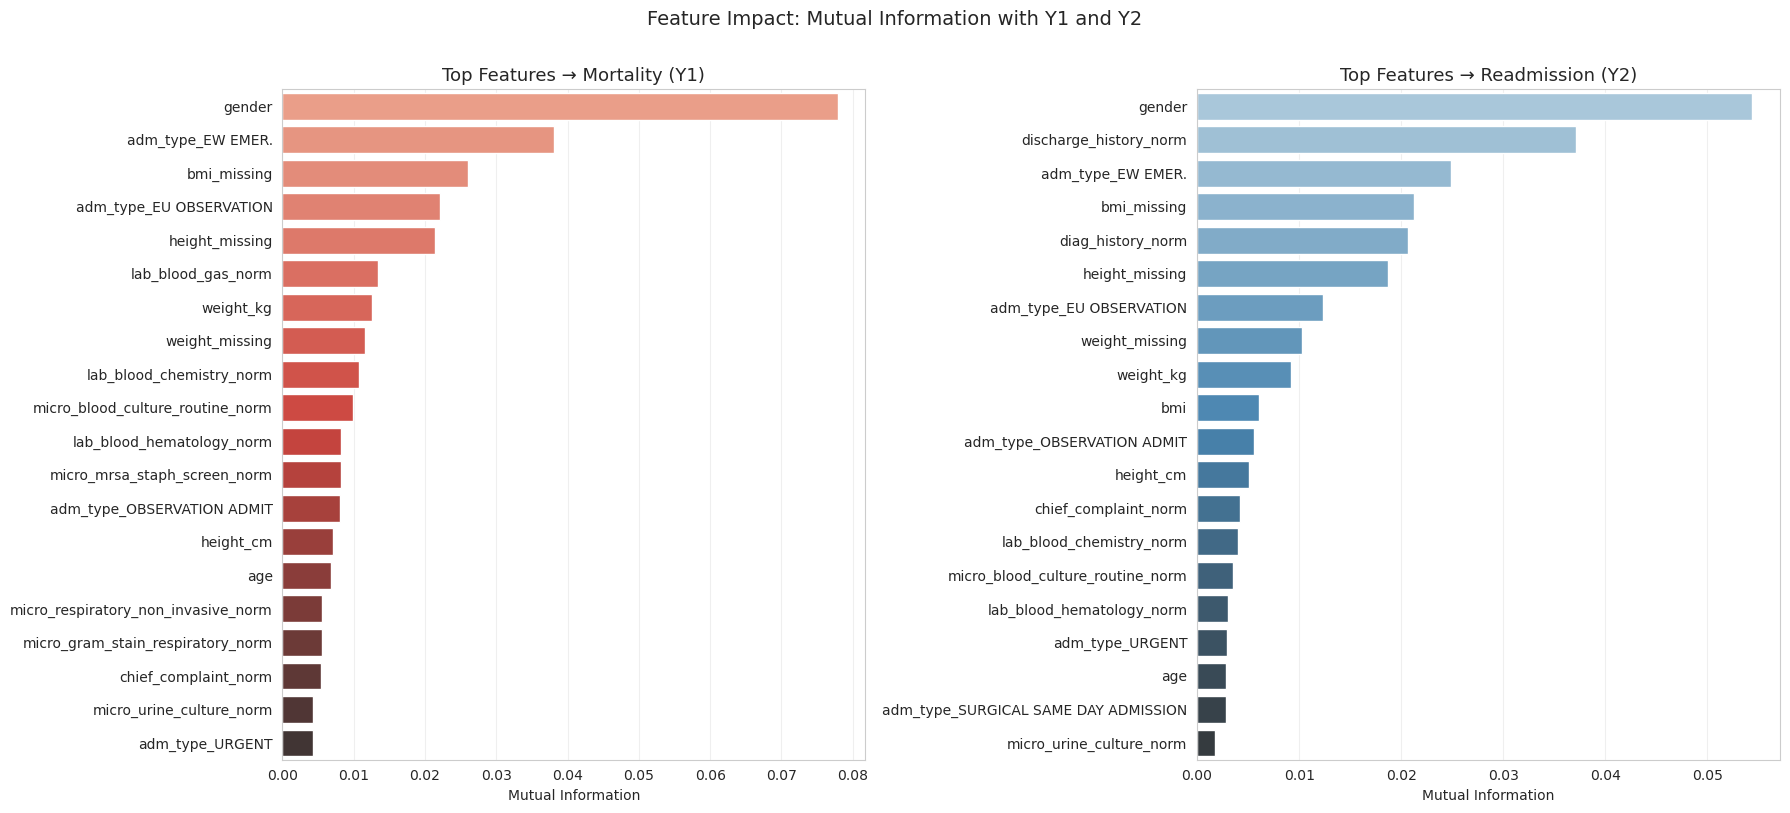

In [6]:
top_n = 20
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, col, title, color in [
    (axes[0], "MI_mortality",   "Top Features → Mortality (Y1)",   "Reds_d"),
    (axes[1], "MI_readmission", "Top Features → Readmission (Y2)", "Blues_d"),
]:
    top = mi_df.nlargest(top_n, col)
    sns.barplot(x=col, y="feature", data=top, hue="feature",
                palette=color, legend=False, ax=ax)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Mutual Information")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.3)

plt.suptitle("Feature Impact: Mutual Information with Y1 and Y2", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

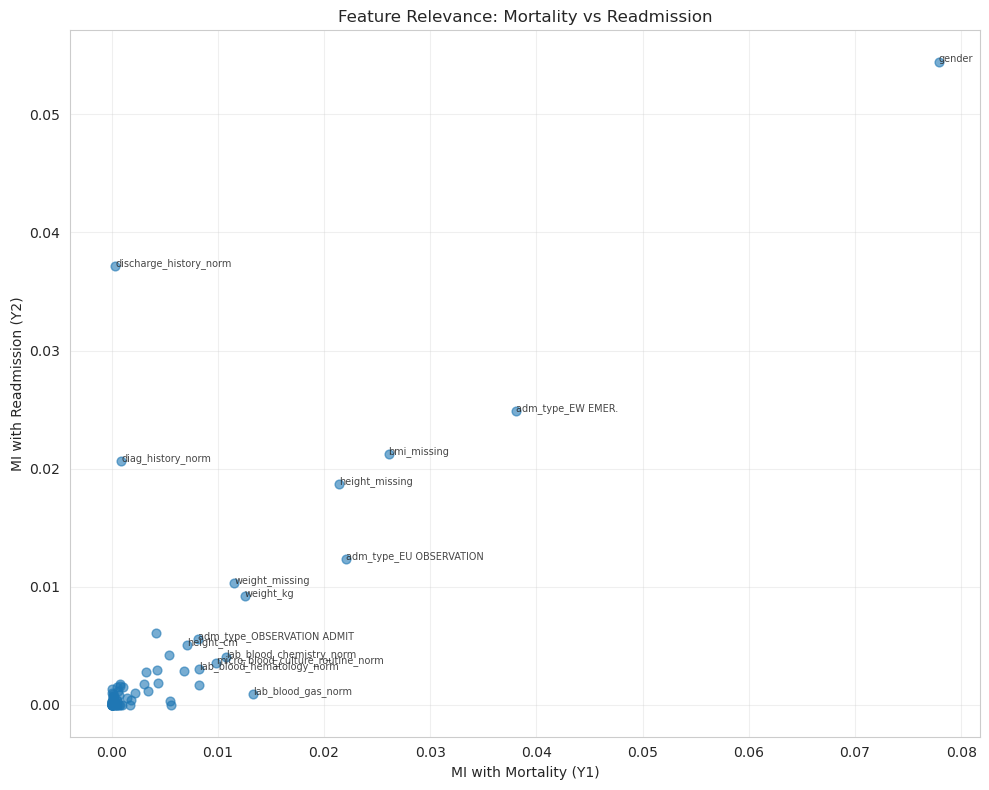

In [7]:
# Scatter: features important for both vs one outcome only
plt.figure(figsize=(10, 8))
plt.scatter(mi_df["MI_mortality"], mi_df["MI_readmission"], alpha=0.6, s=40)

# Annotate top-15 by combined MI
mi_df["MI_combined"] = mi_df["MI_mortality"] + mi_df["MI_readmission"]
for _, row in mi_df.nlargest(15, "MI_combined").iterrows():
    plt.annotate(row["feature"], (row["MI_mortality"], row["MI_readmission"]),
                 fontsize=7, alpha=0.85)

plt.xlabel("MI with Mortality (Y1)")
plt.ylabel("MI with Readmission (Y2)")
plt.title("Feature Relevance: Mortality vs Readmission")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section 5: SHAP Analysis

In [8]:
# --- 5a: Stratified subsample & train surrogate tree models ---
from sklearn.ensemble import RandomForestClassifier
import shap

SHAP_SAMPLE = 30_000
rng = np.random.default_rng(42)


def _stratified_subsample(
    x_mat: np.ndarray,
    labels: np.ndarray,
    n_total: int,
    rand: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """Return a stratified subsample that keeps all positives up to n_total // 2."""
    all_idx  = np.arange(len(labels))
    pos_idx  = all_idx[labels == 1]
    neg_idx  = all_idx[labels == 0]
    n_pos    = min(len(pos_idx), n_total // 2)
    n_neg    = n_total - n_pos
    chosen   = np.concatenate([
        rand.choice(pos_idx, n_pos, replace=False),
        rand.choice(neg_idx, n_neg, replace=False),
    ])
    return x_mat[chosen], labels[chosen]


x_shap_y1, y_shap_y1 = _stratified_subsample(X_y1, y1, SHAP_SAMPLE, rng)
x_shap_y2, y_shap_y2 = _stratified_subsample(X_y2, y2, SHAP_SAMPLE, rng)

print(f"Y1 subsample — pos: {int(y_shap_y1.sum()):,}  neg: {int((1 - y_shap_y1).sum()):,}")
print(f"Y2 subsample — pos: {int(y_shap_y2.sum()):,}  neg: {int((1 - y_shap_y2).sum()):,}")

print("Training surrogate model for Y1 (mortality)...")
clf_y1 = RandomForestClassifier(
    n_estimators=200, max_depth=7, min_samples_leaf=20,
    n_jobs=-1, random_state=42, class_weight="balanced",
)
clf_y1.fit(x_shap_y1, y_shap_y1)

print("Training surrogate model for Y2 (readmission)...")
clf_y2 = RandomForestClassifier(
    n_estimators=200, max_depth=7, min_samples_leaf=20,
    n_jobs=-1, random_state=42, class_weight="balanced",
)
clf_y2.fit(x_shap_y2, y_shap_y2)

print("Models trained.")

Y1 subsample — pos: 11,801  neg: 18,199
Y2 subsample — pos: 15,000  neg: 15,000
Training surrogate model for Y1 (mortality)...


Training surrogate model for Y2 (readmission)...


Models trained.


In [9]:
# --- 5b: Compute SHAP values via TreeExplainer ---
# shap 0.46+ returns a 3-D ndarray (n_samples, n_features, n_classes)
# for multi-class models; older versions returned a list. Handle both.

def _extract_positive_class_shap(raw: object) -> 'np.ndarray':
    """Return the positive-class SHAP matrix regardless of shap version."""
    if isinstance(raw, list):
        return raw[1]                  # old: [class0_arr, class1_arr]
    arr = np.asarray(raw)
    if arr.ndim == 3:
        return arr[:, :, 1]            # new: (n_samples, n_features, n_classes)
    return arr                         # already (n_samples, n_features)


print("Computing SHAP values for Y1...")
explainer_y1 = shap.TreeExplainer(clf_y1)
sv_y1 = _extract_positive_class_shap(explainer_y1.shap_values(x_shap_y1))

print("Computing SHAP values for Y2...")
explainer_y2 = shap.TreeExplainer(clf_y2)
sv_y2 = _extract_positive_class_shap(explainer_y2.shap_values(x_shap_y2))

print(f"SHAP matrix Y1: {sv_y1.shape}")
print(f"SHAP matrix Y2: {sv_y2.shape}")

Computing SHAP values for Y1...


Computing SHAP values for Y2...


SHAP matrix Y1: (30000, 72)
SHAP matrix Y2: (30000, 72)


## Section 6: SHAP Visualisation

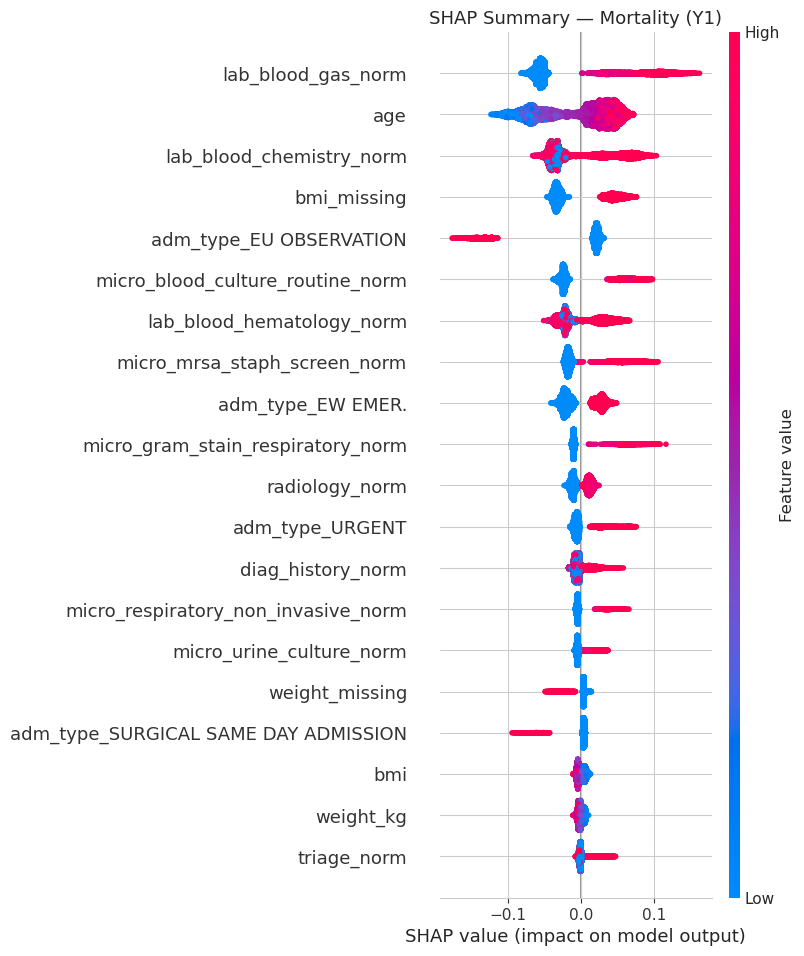

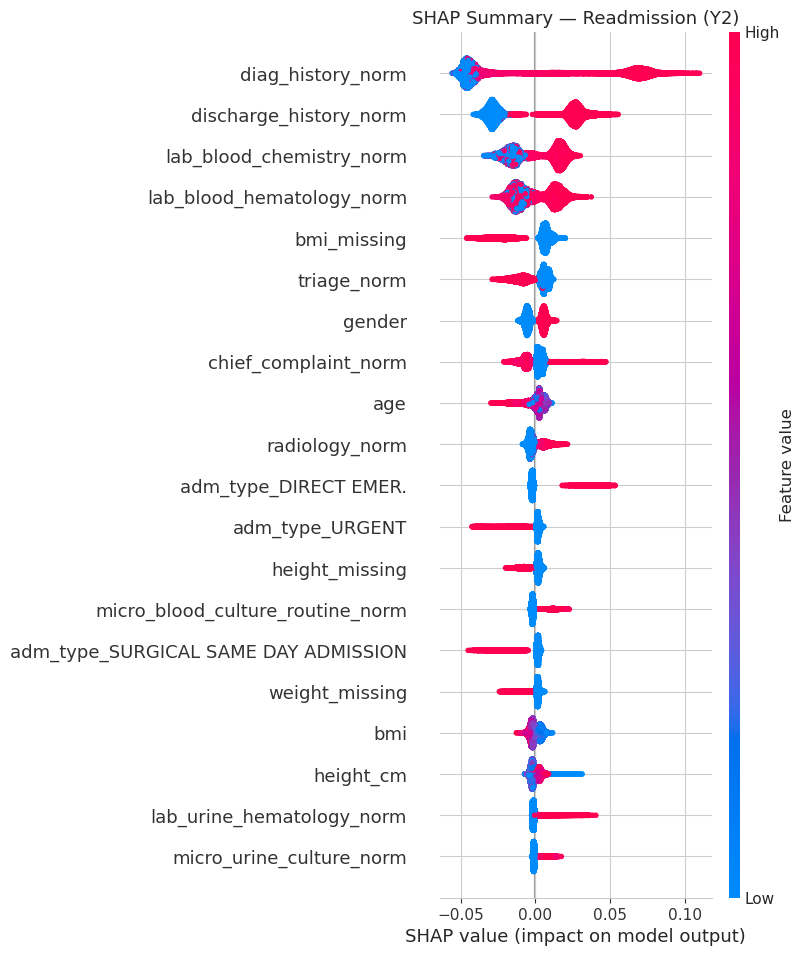

In [10]:
# --- 6a: Beeswarm (summary) plots — one figure per outcome ---
# SHAP manages its own figure layout (colorbar, tight_layout); embedding
# it inside a subplot grid triggers layout conflicts.  Use separate figures.
for sv, x_data, title in [
    (sv_y1, x_shap_y1, "SHAP Summary — Mortality (Y1)"),
    (sv_y2, x_shap_y2, "SHAP Summary — Readmission (Y2)"),
]:
    plt.figure(figsize=(10, 9))
    shap.summary_plot(
        sv, x_data, feature_names=feature_cols,
        max_display=20, show=False, plot_type="dot",
    )
    plt.title(title, fontsize=13)
    plt.show()

=== Mean |SHAP| — Top 30 by Mortality (Y1) ===
                             feature  mean_shap_y1  mean_shap_y2
                  lab_blood_gas_norm      0.066890      0.000531
                                 age      0.042949      0.004586
            lab_blood_chemistry_norm      0.040805      0.015406
                         bmi_missing      0.037851      0.011267
             adm_type_EU OBSERVATION      0.037494      0.000874
    micro_blood_culture_routine_norm      0.034204      0.003253
           lab_blood_hematology_norm      0.027123      0.012173
        micro_mrsa_staph_screen_norm      0.025950      0.000163
                   adm_type_EW EMER.      0.023261      0.001643
   micro_gram_stain_respiratory_norm      0.016127      0.000073
                      radiology_norm      0.011363      0.004134
                     adm_type_URGENT      0.010377      0.003430
                   diag_history_norm      0.008262      0.049696
 micro_respiratory_non_invasive_norm      0

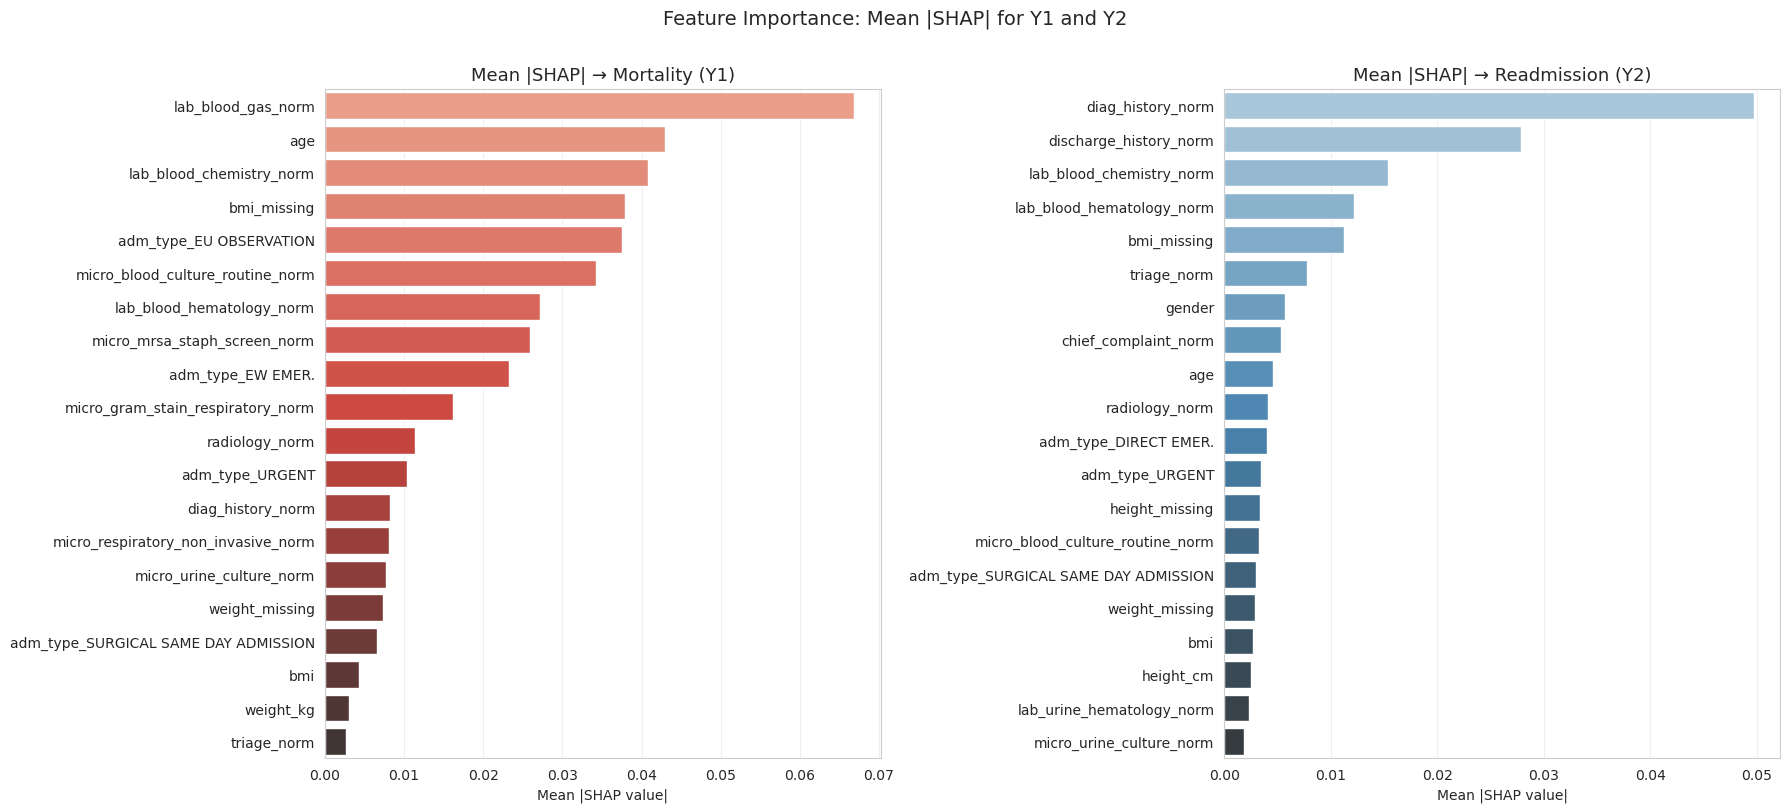

In [11]:
# --- 6b: Mean |SHAP| bar charts (top-20 per outcome) ---
mean_shap_y1 = np.abs(sv_y1).mean(axis=0)
mean_shap_y2 = np.abs(sv_y2).mean(axis=0)

shap_bar_df = pd.DataFrame({
    "feature":        feature_cols,
    "mean_shap_y1":   mean_shap_y1,
    "mean_shap_y2":   mean_shap_y2,
})
shap_bar_df["combined"] = shap_bar_df["mean_shap_y1"] + shap_bar_df["mean_shap_y2"]

print("=== Mean |SHAP| — Top 30 by Mortality (Y1) ===")
print(shap_bar_df.nlargest(30, "mean_shap_y1")[["feature", "mean_shap_y1", "mean_shap_y2"]].to_string(index=False))

print("\n=== Mean |SHAP| — Top 30 by Readmission (Y2) ===")
print(shap_bar_df.nlargest(30, "mean_shap_y2")[["feature", "mean_shap_y1", "mean_shap_y2"]].to_string(index=False))

print("\n=== Mean |SHAP| — Full ranking by combined ===")
print(shap_bar_df.sort_values("combined", ascending=False).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, col, title, palette in [
    (axes[0], "mean_shap_y1", "Mean |SHAP| → Mortality (Y1)",   "Reds_d"),
    (axes[1], "mean_shap_y2", "Mean |SHAP| → Readmission (Y2)", "Blues_d"),
]:
    top = shap_bar_df.nlargest(20, col)
    sns.barplot(x=col, y="feature", data=top, hue="feature",
                palette=palette, legend=False, ax=ax)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.3)

plt.suptitle("Feature Importance: Mean |SHAP| for Y1 and Y2", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Spearman ρ (SHAP vs MI) — Y1 mortality  : 0.8621
Spearman ρ (SHAP vs MI) — Y2 readmission: 0.8173

=== SHAP vs MI — full feature table (sorted by mean_shap_y1) ===
                               feature  mean_shap_y1  mean_shap_y2  MI_mortality  MI_readmission
                    lab_blood_gas_norm      0.066890      0.000531  1.334966e-02        0.000912
                                   age      0.042949      0.004586  6.833515e-03        0.002832
              lab_blood_chemistry_norm      0.040805      0.015406  1.077662e-02        0.004027
                           bmi_missing      0.037851      0.011267  2.608247e-02        0.021222
               adm_type_EU OBSERVATION      0.037494      0.000874  2.205046e-02        0.012340
      micro_blood_culture_routine_norm      0.034204      0.003253  9.856379e-03        0.003497
             lab_blood_hematology_norm      0.027123      0.012173  8.273080e-03        0.002980
          micro_mrsa_staph_screen_norm      0.025950      0.

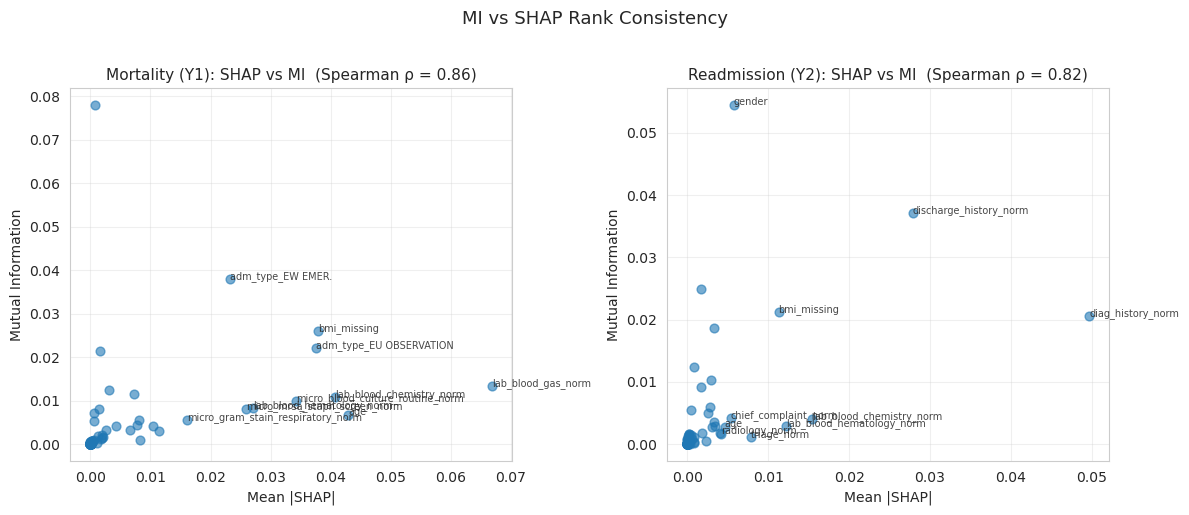

In [12]:
# --- 6c: MI rank vs SHAP rank correlation scatter ---
shap_merge = shap_bar_df[["feature", "mean_shap_y1", "mean_shap_y2"]].merge(
    mi_df[["feature", "MI_mortality", "MI_readmission"]], on="feature"
)

rho_y1 = shap_merge["mean_shap_y1"].corr(shap_merge["MI_mortality"],   method="spearman")
rho_y2 = shap_merge["mean_shap_y2"].corr(shap_merge["MI_readmission"], method="spearman")

print(f"Spearman ρ (SHAP vs MI) — Y1 mortality  : {rho_y1:.4f}")
print(f"Spearman ρ (SHAP vs MI) — Y2 readmission: {rho_y2:.4f}")

print("\n=== SHAP vs MI — full feature table (sorted by mean_shap_y1) ===")
print(
    shap_merge
    .sort_values("mean_shap_y1", ascending=False)
    .to_string(index=False)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, shap_col, mi_col, title in [
    (axes[0], "mean_shap_y1", "MI_mortality",   "Mortality (Y1): SHAP vs MI"),
    (axes[1], "mean_shap_y2", "MI_readmission", "Readmission (Y2): SHAP vs MI"),
]:
    ax.scatter(shap_merge[shap_col], shap_merge[mi_col], alpha=0.6, s=40)
    top10 = shap_merge.nlargest(10, shap_col)
    for _, row in top10.iterrows():
        ax.annotate(row["feature"], (row[shap_col], row[mi_col]), fontsize=7, alpha=0.85)
    corr = shap_merge[shap_col].corr(shap_merge[mi_col], method="spearman")
    ax.set_title(f"{title}  (Spearman ρ = {corr:.2f})", fontsize=11)
    ax.set_xlabel("Mean |SHAP|")
    ax.set_ylabel("Mutual Information")
    ax.grid(alpha=0.3)

plt.suptitle("MI vs SHAP Rank Consistency", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Section 7: Reward Model SHAP (GradientExplainer)

Runs SHAP directly on the trained MLP using `shap.GradientExplainer`.
DeepExplainer fails with BatchNorm1d (additivity violation); GradientExplainer
computes actual gradients through the full computation graph and handles BN correctly.
SHAP values are aggregated per feature group (mean |SHAP| over each group's 128 dims).

In [13]:
# --- 7a: Load model and config ---
import sys
import torch
from typing import cast, Any
import numpy as np

sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / 'src/reward_model'))
from src.reward_model.reward_model import RewardModel
from src.reward_model.reward_model_config import load_and_validate_config

CHECKPOINT_PATH = REPO_ROOT / 'data/reward_model/checkpoints/best_model.pt'
CONFIG_PATH     = REPO_ROOT / 'config/reward_model.yaml'
REDUCED_DATA    = REPO_ROOT / 'data/preprocessing/reduced/reduced_cdss_dataset.parquet'

rm_config    = load_and_validate_config(str(CONFIG_PATH))
reward_model = RewardModel(rm_config)
ckpt         = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)
reward_model.load_state_dict(ckpt['model_state_dict'])
reward_model.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
reward_model = reward_model.to(device)

print(f'Loaded checkpoint — epoch {ckpt["epoch"]}, best_dev_loss={ckpt["best_dev_loss"]:.4f}')
print(f'INPUT_DIM={rm_config.INPUT_DIM}  EMBEDDING_DIM={rm_config.EMBEDDING_DIM}  device={device}')


Loaded checkpoint — epoch 10, best_dev_loss=0.3490
INPUT_DIM=7048  EMBEDDING_DIM=128  device=cuda


In [14]:
# --- 7b: Build feature group index from dataset column order ---
# Runtime derivation — never hardcoded per design constraint.
import pyarrow.parquet as pq

schema_rm     = pq.read_schema(str(REDUCED_DATA))
skip_cols     = {'subject_id', 'hadm_id', 'split', 'y1_mortality', 'y2_readmission'}
feature_cols_rm = [c for c in schema_rm.names if c not in skip_cols]

DEMO_DIM_RM = 8
group_names_rm: list = []
group_slices_rm: dict = {}

offset = 0
for col in feature_cols_rm:
    width = DEMO_DIM_RM if col == 'demographic_vec' else rm_config.EMBEDDING_DIM
    name  = 'demographics' if col == 'demographic_vec' else col.replace('_embedding', '')
    group_names_rm.append(name)
    group_slices_rm[name] = slice(offset, offset + width)
    offset += width

print(f'Feature groups : {len(group_names_rm)}')
print(f'Total input dim: {offset}  (config INPUT_DIM={rm_config.INPUT_DIM})')

Feature groups : 56
Total input dim: 7048  (config INPUT_DIM=7048)


In [15]:
# --- 7c: Load data and assemble feature matrix ---
RM_BACKGROUND = 500
RM_TEST       = 5_000

pf_rm     = pq.ParquetFile(str(REDUCED_DATA))
table_rm  = pf_rm.read(columns=feature_cols_rm + ['y1_mortality', 'y2_readmission'])
df_rm     = table_rm.to_pandas()

parts_rm = [np.stack(df_rm[col].values).astype(np.float32) for col in feature_cols_rm]
x_rm     = np.concatenate(parts_rm, axis=1)
y1_rm    = df_rm['y1_mortality'].values.astype(np.float32)
y2_rm    = df_rm['y2_readmission'].values.astype(np.float32)

print(f'Full feature matrix: {x_rm.shape}')

rng_rm  = np.random.default_rng(0)
bg_idx  = rng_rm.choice(len(x_rm), RM_BACKGROUND, replace=False)
x_bg    = torch.tensor(x_rm[bg_idx], dtype=torch.float32, device=device)

not_bg  = np.setdiff1d(np.arange(len(x_rm)), bg_idx)
test_idx_rm = rng_rm.choice(not_bg, RM_TEST, replace=False)
x_test_rm   = torch.tensor(x_rm[test_idx_rm], dtype=torch.float32, device=device)
y1_test_rm  = y1_rm[test_idx_rm]
y2_test_rm  = y2_rm[test_idx_rm]

print(f'Background: {x_bg.shape}  |  Test: {x_test_rm.shape}')

Full feature matrix: (546028, 7048)
Background: torch.Size([500, 7048])  |  Test: torch.Size([5000, 7048])


In [16]:
# --- 7d: GradientExplainer — separate wrapper per head ---
# GradientExplainer with a (B, 2) dual-output model returns a single
# (n_samples, n_features) array (not a list), so indexing [0]/[1] picks
# rows, not outputs. Using one single-output wrapper per head avoids ambiguity.

class _SingleHeadWrapper(torch.nn.Module):
    """Expose one sigmoid head of RewardModel as a (B, 1) output for GradientExplainer."""

    def __init__(self, base: RewardModel, head_idx: int) -> None:
        super().__init__()
        self.base     = base
        self.head_idx = head_idx

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Return sigmoid probability for the selected head."""
        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x, dtype=torch.float32, device=next(self.base.parameters()).device)
        return torch.sigmoid(self.base(x)[self.head_idx])


wrapper_y1 = _SingleHeadWrapper(reward_model, 0).eval()
wrapper_y2 = _SingleHeadWrapper(reward_model, 1).eval()

x_bg_np = cast(np.ndarray, cast(Any, x_bg))
x_test_np = cast(np.ndarray, cast(Any, x_test_rm))

print('Computing GradientExplainer SHAP values for Y1 (mortality)...')
shap_raw_y1_rm = shap.GradientExplainer(wrapper_y1, x_bg_np).shap_values(x_test_rm) # type: ignore
print(f'  raw output type={type(shap_raw_y1_rm)}, '
      f'shape={np.array(shap_raw_y1_rm).shape}')

print('Computing GradientExplainer SHAP values for Y2 (readmission)...')
shap_raw_y2_rm = shap.GradientExplainer(wrapper_y2, x_bg_np).shap_values(x_test_rm) # type: ignore
print(f'  raw output type={type(shap_raw_y2_rm)}, '
      f'shape={np.array(shap_raw_y2_rm).shape}')


def _to_2d(raw: object) -> np.ndarray:
    """Coerce GradientExplainer output to (n_samples, n_features) regardless of format."""
    arr = np.array(raw[0]) if isinstance(raw, list) else np.array(raw)
    if arr.ndim == 3:
        arr = arr[:, :, 0]   # (n_samples, n_features, 1) -> (n_samples, n_features)
    return arr


sv_rm_y1 = _to_2d(shap_raw_y1_rm)
sv_rm_y2 = _to_2d(shap_raw_y2_rm)

print(f'SHAP matrix Y1: {sv_rm_y1.shape}')
print(f'SHAP matrix Y2: {sv_rm_y2.shape}')

Computing GradientExplainer SHAP values for Y1 (mortality)...


  raw output type=<class 'numpy.ndarray'>, shape=(5000, 7048, 1)
Computing GradientExplainer SHAP values for Y2 (readmission)...


  raw output type=<class 'numpy.ndarray'>, shape=(5000, 7048, 1)
SHAP matrix Y1: (5000, 7048)
SHAP matrix Y2: (5000, 7048)


In [17]:
# --- 7e: Aggregate SHAP to group level (mean |SHAP| per group) ---

# Y2: deceased patients have NaN label — exclude them from Y2 aggregation
y2_valid_mask = ~np.isnan(y2_test_rm)

rows_y1 = sv_rm_y1                       # all rows valid for Y1
rows_y2 = sv_rm_y2[y2_valid_mask]        # survivors only for Y2

group_shap_y1 = {name: float(np.abs(rows_y1[:, sl]).mean()) for name, sl in group_slices_rm.items()}
group_shap_y2 = {name: float(np.abs(rows_y2[:, sl]).mean()) for name, sl in group_slices_rm.items()}

rm_shap_df = pd.DataFrame({
    'feature':       list(group_shap_y1.keys()),
    'rm_shap_y1':    list(group_shap_y1.values()),
    'rm_shap_y2':    list(group_shap_y2.values()),
})
rm_shap_df['combined'] = rm_shap_df['rm_shap_y1'] + rm_shap_df['rm_shap_y2']

print('=== RM DeepExplainer — Mean |SHAP| per group, Top 30 by Mortality (Y1) ===')
print(rm_shap_df.nlargest(30, 'rm_shap_y1')[['feature', 'rm_shap_y1', 'rm_shap_y2']].to_string(index=False))

print('\n=== RM DeepExplainer — Mean |SHAP| per group, Top 30 by Readmission (Y2) ===')
print(rm_shap_df.nlargest(30, 'rm_shap_y2')[['feature', 'rm_shap_y1', 'rm_shap_y2']].to_string(index=False))

print('\n=== RM DeepExplainer — Full ranking by combined ===')
print(rm_shap_df.sort_values('combined', ascending=False).to_string(index=False))

=== RM DeepExplainer — Mean |SHAP| per group, Top 30 by Mortality (Y1) ===
                        feature  rm_shap_y1  rm_shap_y2
                   demographics    0.019850    0.012162
                      radiology    0.001716    0.001017
            lab_blood_chemistry    0.001328    0.001191
           lab_blood_hematology    0.001126    0.001047
                   diag_history    0.000983    0.002216
                chief_complaint    0.000658    0.000948
                  lab_blood_gas    0.000597    0.000224
                         triage    0.000531    0.000390
              discharge_history    0.000400    0.000723
           lab_urine_hematology    0.000298    0.000257
            lab_urine_chemistry    0.000211    0.000223
            micro_urine_culture    0.000135    0.000099
    micro_blood_culture_routine    0.000070    0.000031
 micro_respiratory_non_invasive    0.000066    0.000024
            micro_wound_culture    0.000060    0.000067
   micro_gram_stain_respirato

In [18]:
# --- 7f: Surrogate vs RM SHAP — Spearman rank correlation ---

# Normalize shap_bar_df feature names to match rm_shap_df macro-group names
_demo_features = {"age", "gender", "height_cm", "weight_kg", "bmi",
                  "height_missing", "weight_missing", "bmi_missing"}

def _map_feature(name):
    if name in _demo_features or name.startswith("adm_type_"):
        return "demographics"
    if name.endswith("_norm"):
        return name[:-len("_norm")]
    return name

shap_bar_grouped = (
    shap_bar_df
    .assign(feature=shap_bar_df['feature'].map(_map_feature))
    .groupby('feature', as_index=False)[['mean_shap_y1', 'mean_shap_y2']]
    .sum()
)

rm_merge = rm_shap_df[['feature', 'rm_shap_y1', 'rm_shap_y2']].merge(
    shap_bar_grouped[['feature', 'mean_shap_y1', 'mean_shap_y2']], on='feature'
)

rho_y1_rm = rm_merge['rm_shap_y1'].corr(rm_merge['mean_shap_y1'], method='spearman')
rho_y2_rm = rm_merge['rm_shap_y2'].corr(rm_merge['mean_shap_y2'], method='spearman')

print(f'Spearman ρ (RM vs Surrogate SHAP) — Y1 mortality  : {rho_y1_rm:.4f}')
print(f'Spearman ρ (RM vs Surrogate SHAP) — Y2 readmission: {rho_y2_rm:.4f}')

print('\n=== RM vs Surrogate SHAP — full group comparison (sorted by rm_shap_y1) ===')
print(rm_merge.sort_values('rm_shap_y1', ascending=False).to_string(index=False))

Spearman ρ (RM vs Surrogate SHAP) — Y1 mortality  : nan
Spearman ρ (RM vs Surrogate SHAP) — Y2 readmission: nan

=== RM vs Surrogate SHAP — full group comparison (sorted by rm_shap_y1) ===
Empty DataFrame
Columns: [feature, rm_shap_y1, rm_shap_y2, mean_shap_y1, mean_shap_y2]
Index: []


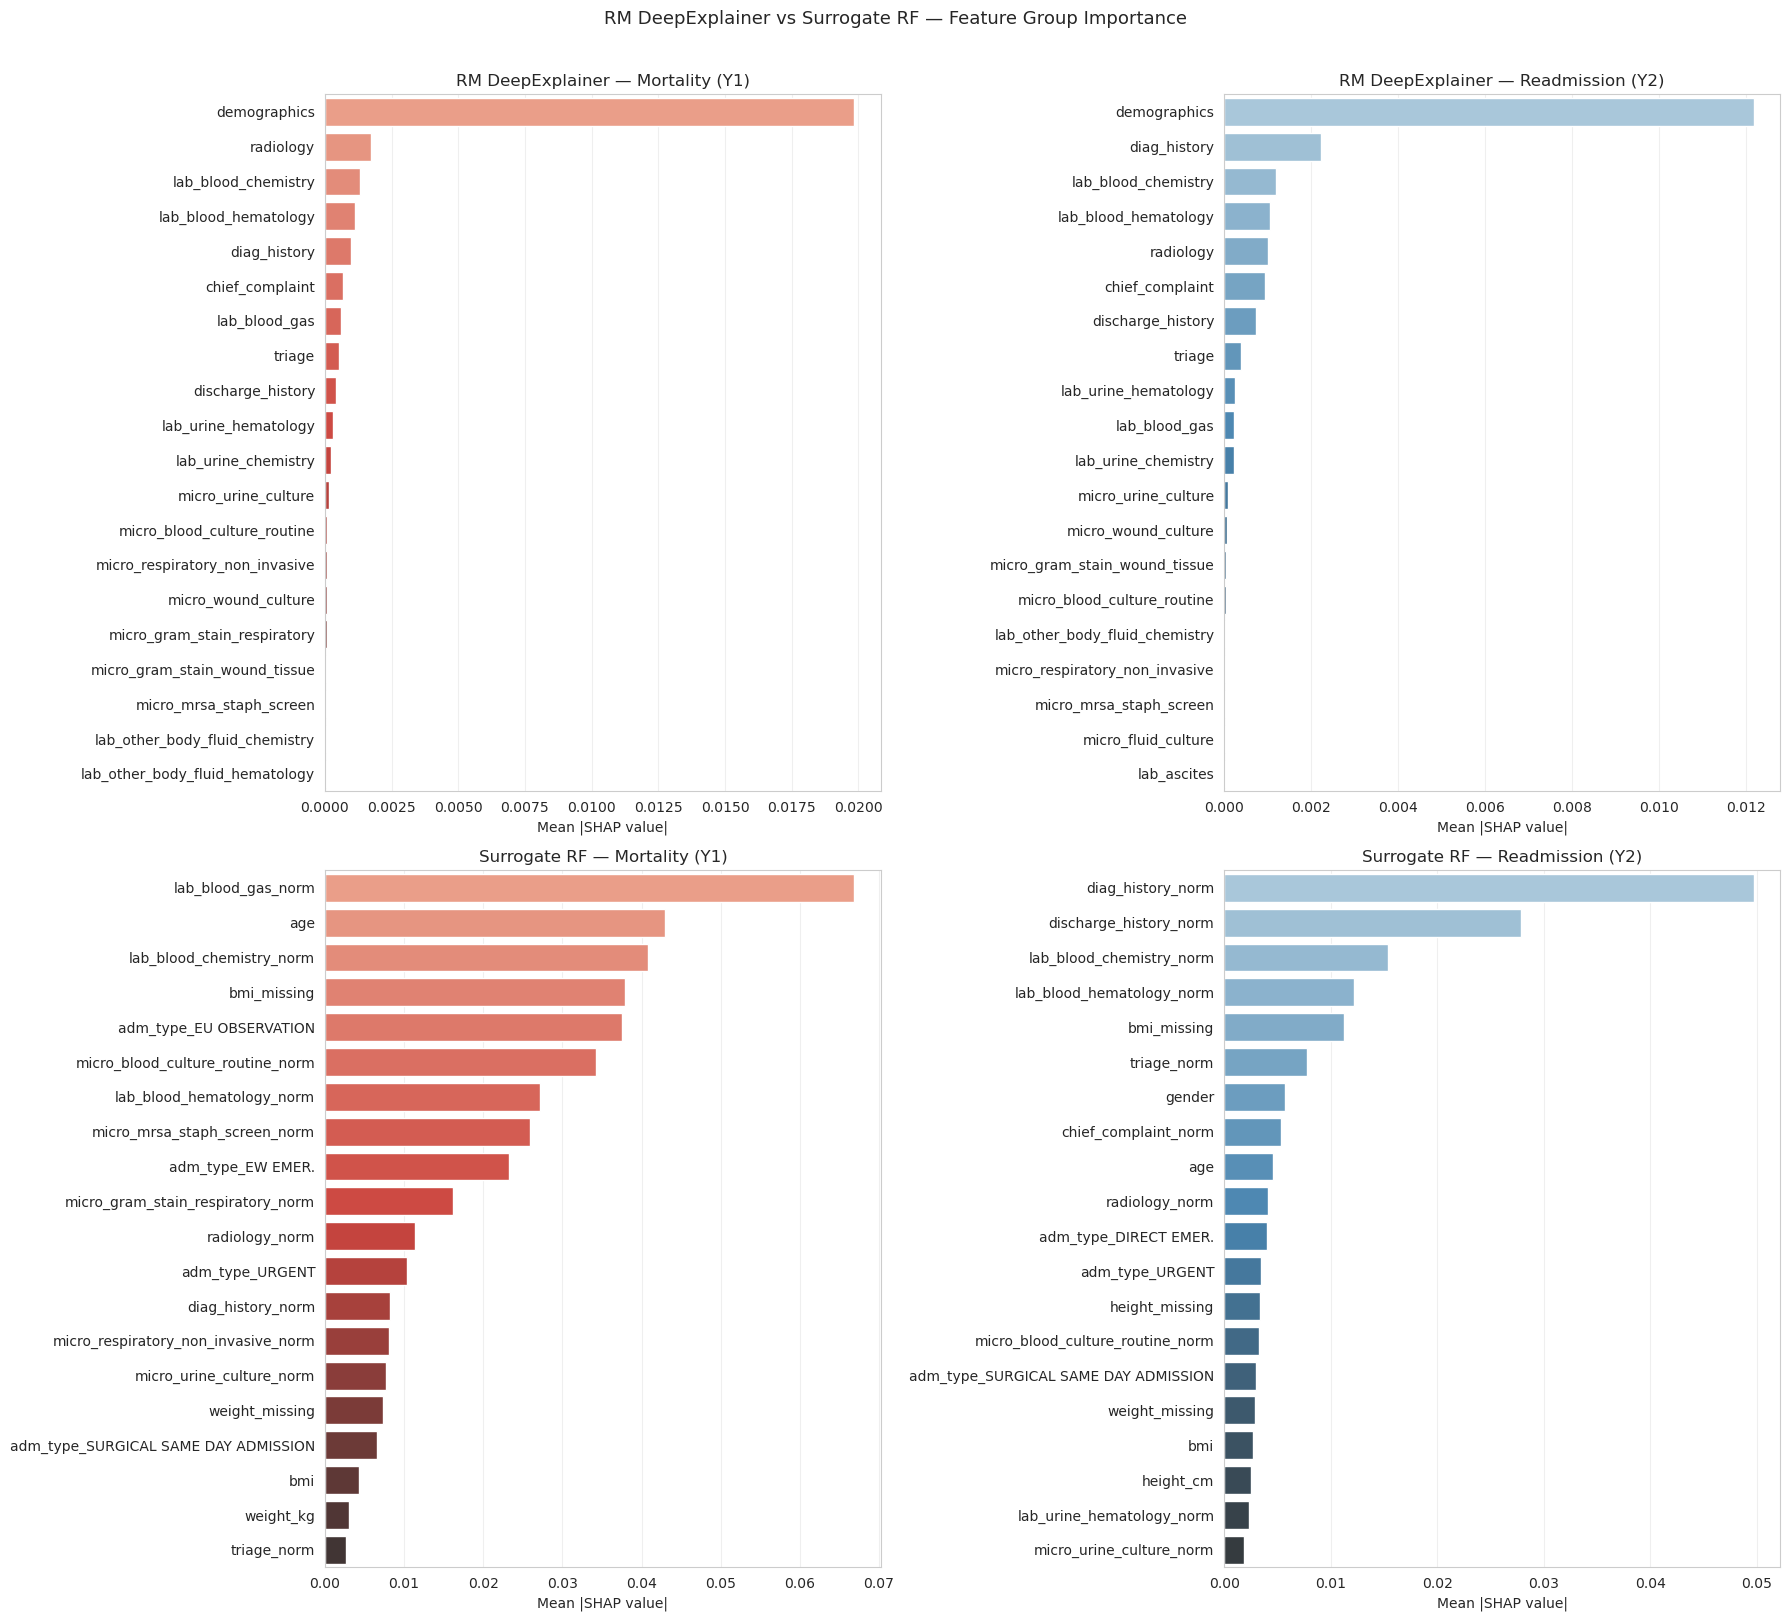

In [19]:
# --- 7g: Side-by-side bar charts: RM SHAP vs Surrogate SHAP ---
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

plot_cfg = [
    (axes[0, 0], 'rm_shap_y1',    rm_shap_df,  'RM DeepExplainer — Mortality (Y1)',    'Reds_d'),
    (axes[0, 1], 'rm_shap_y2',    rm_shap_df,  'RM DeepExplainer — Readmission (Y2)',  'Blues_d'),
    (axes[1, 0], 'mean_shap_y1',  shap_bar_df, 'Surrogate RF — Mortality (Y1)',         'Reds_d'),
    (axes[1, 1], 'mean_shap_y2',  shap_bar_df, 'Surrogate RF — Readmission (Y2)',       'Blues_d'),
]

for ax, col, src_df, title, palette in plot_cfg:
    top = src_df.nlargest(20, col)
    sns.barplot(x=col, y='feature', data=top, hue='feature',
                palette=palette, legend=False, ax=ax)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_ylabel('')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('RM DeepExplainer vs Surrogate RF — Feature Group Importance', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()